In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)


Pandas version: 2.2.2
NumPy version: 2.0.2


In [2]:

data = {
    'UserID': [1, 1, 1, 2, 2, 3, 3, 4, 4, 5],
    'Movie': [
        'Inception', 'Interstellar', 'Titanic',
        'Inception', 'Titanic',
        'Interstellar', 'Avengers',
        'Avengers', 'Titanic',
        'Inception'
    ],
    'Rating': [5, 4, 3, 4, 5, 5, 4, 3, 4, 5]
}

df = pd.DataFrame(data)
df


,UserID,Movie,Rating
0,1,Inception,5
1,1,Interstellar,4
2,1,Titanic,3
3,2,Inception,4
4,2,Titanic,5
5,3,Interstellar,5
6,3,Avengers,4
7,4,Avengers,3
8,4,Titanic,4
9,5,Inception,5


In [3]:


user_item_matrix = df.pivot_table(
    index='UserID',
    columns='Movie',
    values='Rating'
)

user_item_matrix


Movie,Avengers,Inception,Interstellar,Titanic
UserID,,,,
1,NaN,5.0,4.0,3.0
2,NaN,4.0,NaN,5.0
3,4.0,NaN,5.0,NaN
4,3.0,NaN,NaN,4.0
5,NaN,5.0,NaN,NaN


In [4]:


user_item_filled = user_item_matrix.fillna(0)
user_item_filled


Movie,Avengers,Inception,Interstellar,Titanic
UserID,,,,
1,0.0,5.0,4.0,3.0
2,0.0,4.0,0.0,5.0
3,4.0,0.0,5.0,0.0
4,3.0,0.0,0.0,4.0
5,0.0,5.0,0.0,0.0


In [5]:


from sklearn.metrics.pairwise import cosine_similarity

user_similarity = cosine_similarity(user_item_filled)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

user_similarity_df


UserID,1,2,3,4,5
UserID,,,,,
1,1.000000,0.773021,0.441726,0.339411,0.707107
2,0.773021,1.000000,0.000000,0.624695,0.624695
3,0.441726,0.000000,1.000000,0.374817,0.000000
4,0.339411,0.624695,0.374817,1.000000,0.000000
5,0.707107,0.624695,0.000000,0.000000,1.000000


In [6]:


def recommend_movies(user_id, user_item_matrix, similarity_df, top_n=2):
    # Get similarity scores for the target user
    similar_users = similarity_df[user_id].sort_values(ascending=False)

    # Exclude the user itself
    similar_users = similar_users.drop(user_id)

    # Get movies the target user has already rated
    user_rated_movies = user_item_matrix.loc[user_id]
    user_rated_movies = user_rated_movies[user_rated_movies > 0].index.tolist()

    recommendations = {}

    # Loop through similar users
    for similar_user, similarity_score in similar_users.items():
        if similarity_score <= 0:
            continue

        # Movies rated by similar user
        similar_user_ratings = user_item_matrix.loc[similar_user]

        for movie, rating in similar_user_ratings.items():
            if movie not in user_rated_movies and rating > 0:
                if movie not in recommendations:
                    recommendations[movie] = 0
                recommendations[movie] += similarity_score * rating

    # Sort recommendations
    recommended_movies = sorted(
        recommendations.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return recommended_movies[:top_n]


In [7]:


user_id = 1
recommended = recommend_movies(user_id, user_item_filled, user_similarity_df)

print(f"Recommended movies for User {user_id}:")
for movie, score in recommended:
    print(movie)


Recommended movies for User 1:
Avengers


In [8]:


def evaluate_recommendations(user_id, recommendations, user_item_matrix):
    already_rated = user_item_matrix.loc[user_id]
    already_rated = already_rated[already_rated > 0].index.tolist()

    print(f"User {user_id} already rated:", already_rated)
    print("Recommended movies (not previously rated):")

    for movie, _ in recommendations:
        if movie not in already_rated:
            print("✔", movie)

# Evaluate for user 1
evaluate_recommendations(1, recommended, user_item_filled)


User 1 already rated: ['Inception', 'Interstellar', 'Titanic']
Recommended movies (not previously rated):
✔ Avengers


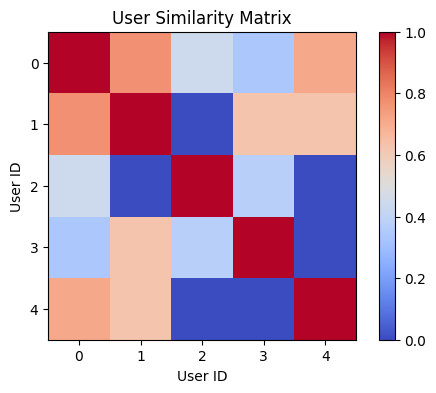

In [9]:


plt.figure(figsize=(6,4))
plt.imshow(user_similarity_df, cmap='coolwarm')
plt.colorbar()
plt.title("User Similarity Matrix")
plt.xlabel("User ID")
plt.ylabel("User ID")
plt.show()
